# Homework 3
### PSTAT 131/231

## Binary Classification
For this assignment, we will be working with part of a [Kaggle dataset](https://www.kaggle.com/c/titanic/overview) that was the subject of a machine learning competition and is often used for practicing ML models. The goal is classification; specifically, to predict which passengers would survive the [Titanic shipwreck](https://en.wikipedia.org/wiki/Titanic)

For starters import pandas, numpy, matplotlib and seaborn. Then load in the data and familiarize yourself with it by reading the codebook present in the data subdirectory. 

After loading in the data, take a prief look at it using [.head()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html). Take notice that later on we will need to encode `survived` and `pclass` variables.

In [1]:
# Import numpy, pandas, matplotlib.pyplot and seaborn with the usual alias'. Then read in the data. 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set np.random.seed
np.random.seed(131)
# Load in the data and call .head()
titanic = pd.read_csv("/Users/clee/Desktop/PSTAT_131/homework-3-python/data/titanic.csv")
titanic.head()

,passenger_id,survived,pclass,name,sex,age,sib_sp,parch,ticket,fare,cabin,embarked
0,1,No,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,Yes,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,Yes,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,Yes,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,No,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Question 1
Drop the name, ticket, cabin and embarked columns as they will not be used for this assignment. Then take a look at the data and note any potential issues, such as missing values. 

Checking and getting counts for missing values in pandas can be done using [isna()](https://pandas.pydata.org/docs/reference/api/pandas.isna.html) and [sum()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html). 

In [2]:
# Drop the columns that we won't be using
titanic = titanic.drop(columns=["name", "ticket", "cabin", "embarked"])

# Take a look
print(titanic.head())

# Count missing values per column
print("\nMissing values per column:")
print(titanic.isna().sum())

   passenger_id survived  pclass     sex   age  sib_sp  parch     fare
0             1       No       3    male  22.0       1      0   7.2500
1             2      Yes       1  female  38.0       1      0  71.2833
2             3      Yes       3  female  26.0       0      0   7.9250
3             4      Yes       1  female  35.0       1      0  53.1000
4             5       No       3    male  35.0       0      0   8.0500

Missing values per column:
passenger_id      0
survived          0
pclass            0
sex               0
age             177
sib_sp            0
parch             0
fare              0
dtype: int64


After dropping the columns `name`, `ticket`, `cabin`, and `embarked`, we find that the only column with missing values is `age`. It has 177 missing entries. Since age is likely a meaningful predictor of survival, we don't want to throw those rows away so we'll handle the missingness later with an imputer. The other columns (`survived`, `pclass`, `sex`, `sib_sp`, `parch`, `fare`) are complete.

### Question 2
Split the data into training and testing splits, stratifying on the outcome variable, `survived`. You should choose the proportions to split the data into. Verify that the training and testing datasets have the appropriate number of observations by using the native python `len` function.

After you have split the data into training and testing splits, write out why it is a good idea to use stratified sampling for this data.

In [3]:
from sklearn.model_selection import train_test_split

# 80/20 split, stratified on the outcome variable
train, test = train_test_split(
    titanic,
    test_size=0.2,
    stratify=titanic["survived"],
    random_state=131
)

print(f"Training observations: {len(train)}")
print(f"Testing observations:  {len(test)}")
print(f"Total:                 {len(train) + len(test)} (original: {len(titanic)})")

# Confirm stratification preserved survival proportions
print("\nSurvival proportions in training set:")
print(train["survived"].value_counts(normalize=True))
print("\nSurvival proportions in testing set:")
print(test["survived"].value_counts(normalize=True))

Training observations: 712
Testing observations:  179
Total:                 891 (original: 891)

Survival proportions in training set:
survived
No     0.616573
Yes    0.383427
Name: proportion, dtype: float64

Survival proportions in testing set:
survived
No     0.614525
Yes    0.385475
Name: proportion, dtype: float64


**Why stratified sampling?** 

We want to use stratified sampleing because the outcome variable `survived` is imbalanced. This is because only about 38% of passengers in the dataset survived, while ~61.6% did not. With a plain random split there is a real risk that one of the splits ends up with a noticeably different survival rate than the other, especially since the dataset is fairly small (891 observations). Stratifying on `survived` forces the training and testing sets to have the same proportion of survivors as the full dataset, so the model trains on a representative sample of both classes and the test-set evaluation reflects the population we actually care about.

### Question 3
Using the **training** dataset, explore/describe the distribution of the outcome variable survived. 

Create a seaborn [countplot](https://seaborn.pydata.org/generated/seaborn.countplot.html) with sex on the x-axis and hue = 'survived'. Do you think sex will be a good predictor of outcome?

Create one more [countplot](https://seaborn.pydata.org/generated/seaborn.countplot.html) this time with pclass on the x-axis. Do you think passenger class will be a good predictor of the outcome?


survived
No     439
Yes    273
Name: count, dtype: int64

survived
No     0.616573
Yes    0.383427
Name: proportion, dtype: float64


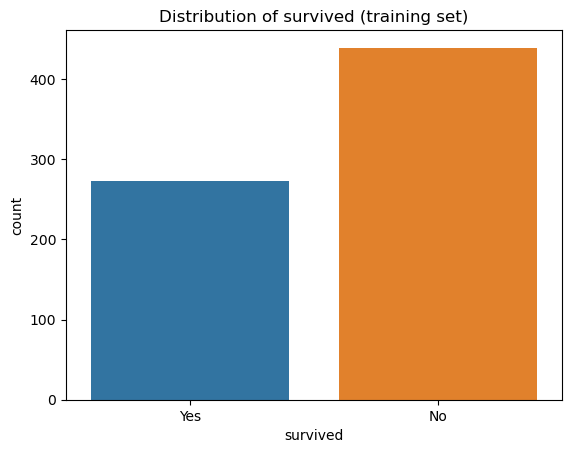

In [4]:
# Distribution of the outcome variable
print(train["survived"].value_counts())
print()
print(train["survived"].value_counts(normalize=True))

sns.countplot(x="survived", data=train)
plt.title("Distribution of survived (training set)")
plt.show()

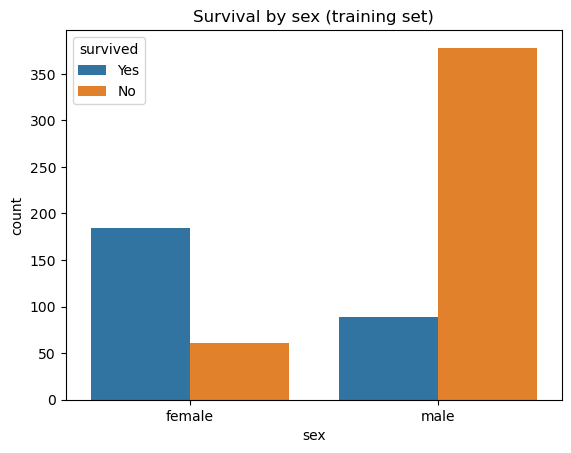

In [5]:
# survived by sex
sns.countplot(x="sex", hue="survived", data=train)
plt.title("Survival by sex (training set)")
plt.show()

**Sex as a predictor?** 

Sex looks like a very strong predictor. Among female passengers, the great majority survived, while among male passengers the great majority died. The classes are clearly separated by sex, so a model should be able to use this variable to discriminate between survivors and non-survivors.

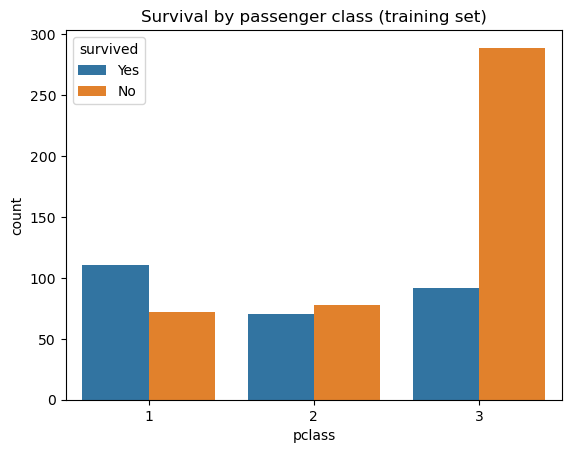

In [6]:
# survived by pclass
sns.countplot(x="pclass", hue="survived", data=train)
plt.title("Survival by passenger class (training set)")
plt.show()

**Passenger class as a predictor?** 

Yes there's a clear ordering here. First-class passengers had roughly even (slightly favorable) survival odds, second-class passengers were close to even, and third-class passengers died at a much higher rate than they survived. Passenger class clearly carries a lot of signal about who survived, so it should also be a useful predictor.

### Question 4
Using the **training** dataset, create a correlation matrix of all continuous variables. Visualize the matrix and describe any patterns you see. Are any predictors correlated with each other? Which ones, and in which direction?


             age    sib_sp     parch      fare
age     1.000000 -0.323105 -0.189615  0.097448
sib_sp -0.323105  1.000000  0.431175  0.142003
parch  -0.189615  0.431175  1.000000  0.215068
fare    0.097448  0.142003  0.215068  1.000000


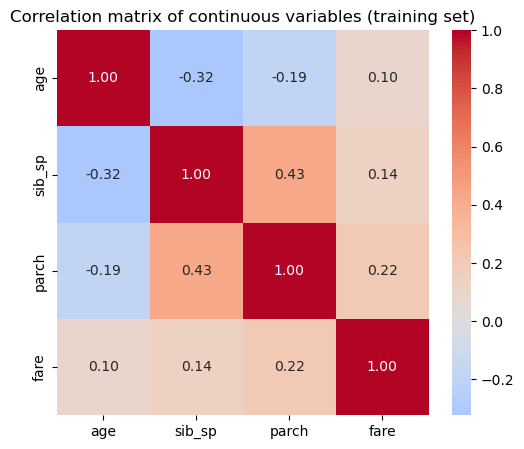

In [7]:
# Continuous variables only
continuous = train[["age", "sib_sp", "parch", "fare"]]

corr = continuous.corr()
print(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix of continuous variables (training set)")
plt.show()

**Patterns in the correlation matrix:**

- I noticed that the strongest relationship is a **positive** correlation between `sib_sp` (siblings/spouses aboard) and `parch` (parents/children aboard) at roughly 0.43. This overall makes sene because passengers travelling with one family member often travelled with several, so people with high values of one tend to have high values of the other.
- `age` is **negatively** correlated with both `sib_sp` (~ −0.32) and `parch` (~ −0.19). Younger passengers tended to be travelling with more family members (children with parents and siblings), while older passengers were more often travelling alone.
- `fare` is mildly **positively** correlated with `parch` (~ 0.22) and `sib_sp` (~ 0.14) this means that larger family groups generally paid more in total fare (and very weakly correlated with) `age`.

Overall none of the correlations are extreme (no |r| above ~0.45), so multicollinearity isn't a serious concern, but `sib_sp`/`parch` and `age`/`sib_sp` are worth keeping in mind.

## Handling Missing Values With Imputers
When setting up a recipe for a model in R imputers can be utilized to handle missing values. In Scikit-learn we will also use imputers, but what exactly are imputers and what is imputation? Generally speaking, imputation is a step that can be taken in preprocessing to deal with missing values.

Expanding on this, imputation can be accomplished in several ways to varying degrees of complexity. On the simpler side, imputation can just be filling in missing values with the mean or median of non-missing values for qualitative variables and the mode for quantative variables. On the more complex side, we can use multivariate imputation where missing data can be filled in with k-nearest neighbors imputation or linear regression imputation for example. K-nearest neighbors imputation uses a k-nearest neighbors algorithm to find 'k' nearest observations to the data containing a missing value and fills it in with the average of that variable in the neighbors. Linear regression imputation fits a model with non-missing values and then predicts what the missing value should be from that.

As our data contains missing values, we will be using imputation in our preprocess function.

### Question 5

Create a preprocess function that does the following: 

* Imputate missing values using [IterativeImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html#sklearn.impute.IterativeImputer) from `sklearn.impute` with estimator = LinearRegression()
* Dummy code categorical variables
* Create interactions between
    * `sex` and `fare`
    * `age` and `fare`

Recall the following:
* Preprocessing should assume the prediction variable is not included
* A dataframe can be permanently modified by your function if you do not operate on a copy of it
* We need to store the column names prior to certain steps that return numpy arrays 

In [8]:
# Keep this line as its required to use the imputer
from sklearn.experimental import enable_iterative_imputer

# Import other functions here
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

# Define the imputer at module scope so it can be fit on the training set and
# then re-used (just .transform) on the testing set.
imputer = IterativeImputer(estimator=LinearRegression(), random_state=131)

def preprocess(titanic_data : pd.DataFrame, is_training : bool) -> pd.DataFrame:
    """
    Takes in titanic data and prepares it for usage in logistic regression modelling
    by dummy coding variables, creating interaction terms and imputing missing values.

    Args:
        titanic_data (pd.DataFrame) : The pandas dataframe containing the abalone dataset.
        is_training (bool) : A boolean that signifies if the imputer needs to be fit or not.
        
    Returns:
        titanic_processed (pd.DataFrame) : The processed titanic dataset, ready for modelling.
    """
    # Operate on a copy so we don't permanently modify the caller's dataframe
    df = titanic_data.copy()

    # Drop the passenger_id column if present — it's just an ID, not a predictor
    if "passenger_id" in df.columns:
        df = df.drop(columns=["passenger_id"])

    # Dummy code the categorical variables (sex and pclass).
    # drop_first=True avoids the dummy-variable trap.
    df["pclass"] = df["pclass"].astype("category")
    df = pd.get_dummies(df, columns=["sex", "pclass"], drop_first=True)

    # get_dummies produces booleans in modern pandas — cast to int so the imputer is happy
    for col in df.columns:
        if df[col].dtype == bool:
            df[col] = df[col].astype(int)

    # Save column names — IterativeImputer returns a numpy array
    cols = df.columns

    # Fit (on training) or just transform (on testing)
    if is_training:
        arr = imputer.fit_transform(df)
    else:
        arr = imputer.transform(df)

    df = pd.DataFrame(arr, columns=cols)

    # Create the interaction terms requested
    df["sex_fare"] = df["sex_male"] * df["fare"]
    df["age_fare"] = df["age"]      * df["fare"]

    return df

#CLAUDE LLM was used here to help me write the code to this function. I started with pseudo code and then with the help of claude was able to write it out.

## Updating The Outcome Variable

For logistic regression we want our outcome variable, `survived`, to change from yes or no to a 1 or 0. However, if we use pd.get_dummies to do this survived splits into two columns. To avoid this, we will make use of the pandas dataframe [.apply()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html) method and a lambda function. 

In python, lambda functions are small one-line functions that are usually used for simple operations or when passing a function as an argument to higher-order functions. In pandas lambda functions can be used in conjunction with the [.apply()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html) method to great effect.

Before moving on, something else we will want to use is a conditional expression. Conditional expressions allow us to easily output separate values depending on a condition and are usually of the form `val_if_true if condition else val_if_false`.

An example of a lambda function that uses a conditional expression is below, feel free to play around with it to get an idea of what it does!

In [9]:
is_two = lambda x : "X is 2!" if x == 2 else "X is not 2!"
print(is_two(2))
print(is_two(3))

X is 2!
X is not 2!


### Question 6

Create a lambda function called update_survived that returns 1 if x is 'Yes' or 0 otherwise. Then, in the **training** dataset, modify the column 'survived' using [.apply()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html). Afterwards, create a copy of the outcome variable `survived`, drop it from the training data and then place the training data into the preprocess function.  

Once preprocessed, initialize a logistic regression model for classification from [sklearn.linear_model.LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) with max_iter = 10000 and fit it with the training data. 

In [11]:
from sklearn.linear_model import LogisticRegression

# Lambda: Yes -> 1, No (or anything not already 1) -> 0.
# Guarded with isinstance so re-running this cell doesn't turn existing 1s into 0s.
update_survived = lambda x : 1 if x == "Yes" else (0 if x == "No" else x)

# Apply on a copy so we don't mutate the original split
train = train.copy()
train["survived"] = train["survived"].apply(update_survived).astype(int)

# Sanity check — should show both classes
print("Class counts in y_train:")
print(train["survived"].value_counts())

# Pull off the outcome, drop it from the predictors, then preprocess
y_train = train["survived"].copy()
X_train_raw = train.drop(columns=["survived"])
X_train = preprocess(X_train_raw, is_training=True)

print("\nProcessed training predictors:")
print(X_train.head())
print("\nShape:", X_train.shape)

# Fit the logistic regression model
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train, y_train)
print("\nLogistic regression fitted.")
print("Training accuracy:", log_reg.score(X_train, y_train))

#CLAUDE LLM was used here again to help with writing psuedo code first, and then followed up with helping to guide through coding

Class counts in y_train:
survived
0    439
1    273
Name: count, dtype: int64

Processed training predictors:
    age  sib_sp  parch    fare  sex_male  pclass_2  pclass_3  sex_fare  \
0  30.0     3.0    0.0  21.000       0.0       1.0       0.0     0.000   
1  26.0     0.0    0.0  10.500       1.0       1.0       0.0    10.500   
2  23.0     0.0    0.0   7.550       0.0       0.0       1.0     0.000   
3   2.0     4.0    1.0  29.125       1.0       0.0       1.0    29.125   
4  23.0     0.0    0.0  13.000       1.0       1.0       0.0    13.000   

   age_fare  
0    630.00  
1    273.00  
2    173.65  
3     58.25  
4    299.00  

Shape: (712, 9)

Logistic regression fitted.
Training accuracy: 0.8188202247191011


### Question 7
Using the same processed data and outcome variable, initialize and fit a [linear discriminant analysis](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html) model for classification. 

In [12]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
print("LDA training accuracy:", lda.score(X_train, y_train))

LDA training accuracy: 0.8019662921348315


### Question 8
Using the same processed data and outcome variable, initialize and fit a [quadratic discriminant analysis](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis.html) model for classification. 

In [13]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
print("QDA training accuracy:", qda.score(X_train, y_train))

QDA training accuracy: 0.8033707865168539


### Question 9
Using the same processed data and outcome variable, initialize and fit a [k-nearest neighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) model for classification. Choose a value of $k$ to try.

In [14]:
from sklearn.neighbors import KNeighborsClassifier
#The following below is from CLAUDE LLM giving a recommedation for k value 
# Try k = 5 — a common default. With ~700 training points this is a reasonable
# starting point: small enough to capture local structure, large enough to smooth noise.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("KNN (k=5) training accuracy:", knn.score(X_train, y_train))

KNN (k=5) training accuracy: 0.8033707865168539


### Question 10
Now that you've fit four different models to your training data, use the processed **training** data with [predict_proba()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict_proba) to generate predictions using each of these 4 models with the processed testing data. Then use the metric of area under the ROC curve to assess the performance of each of the four models. 

In Scikit-learn we use [predict_proba()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict_proba) to get probability estimates that will go into the ROC curve calculations. After using [predict_proba()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict_proba), subset it with [:, 1].

To determine the area under the ROC curve, use [roc_auc_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) from `sklearn.metrics`. 



In [15]:
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": log_reg,
    "LDA":                 lda,
    "QDA":                 qda,
    "KNN (k=5)":           knn,
}

train_aucs = {}
for name, model in models.items():
    probs = model.predict_proba(X_train)[:, 1]
    auc = roc_auc_score(y_train, probs)
    train_aucs[name] = auc
    print(f"{name:25s} training AUC: {auc:.4f}")

Logistic Regression       training AUC: 0.8599
LDA                       training AUC: 0.8584
QDA                       training AUC: 0.8650
KNN (k=5)                 training AUC: 0.8850


### Question 11
Preprocess your **testing** data, applying your lambda function, separating and then dropping the outcome variable, and putting the remaining data through the preprocess function. 

Fit all four models to your **testing** data and report the AUC of each model on the **testing** data. Which model achieved the highest AUC on the **testing** data?

Using your top-performing model, create a confusion matrix and visualize it. Create a plot of its ROC curve.

To create a plot of the ROC curve in Scikit-learn, we use [roc_curve()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html) from `sklearn.metrics` to get our true and false positive rates. Then to visualize the curve, use a matplotlib plot that takes in both rates.

To create a confusion matrix in Scikit-learn, we use [confusion_matrix()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) from `sklearn.metrics`, notice that we use predictions and not probability estimates for the confusion matrix. Then to visualize we use a seaborn heatmap with tick labels. 

How did your best model perform? Compare its **training** and **testing** AUC values. If the values differ, why do you think this is so?

In [16]:
from sklearn.metrics import roc_curve, confusion_matrix

# Apply the same outcome transformation, separate y, drop survived, and preprocess.
# is_training=False so the imputer is just .transform (already fit on training).
test = test.copy()
test["survived"] = test["survived"].apply(update_survived)

y_test = test["survived"].copy()
X_test_raw = test.drop(columns=["survived"])
X_test = preprocess(X_test_raw, is_training=False)

# Compute test AUC for each of the (already-trained) models
test_aucs = {}
for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    test_aucs[name] = auc
    print(f"{name:25s} testing AUC: {auc:.4f}")

# Identify the best model on the test set
best_name = max(test_aucs, key=test_aucs.get)
best_model = models[best_name]
print(f"\nBest model on testing data: {best_name} (AUC = {test_aucs[best_name]:.4f})")

Logistic Regression       testing AUC: 0.8410
LDA                       testing AUC: 0.8464
QDA                       testing AUC: 0.8358
KNN (k=5)                 testing AUC: 0.7988

Best model on testing data: LDA (AUC = 0.8464)


Confusion matrix (rows = true, cols = predicted):
[[93 17]
 [21 48]]


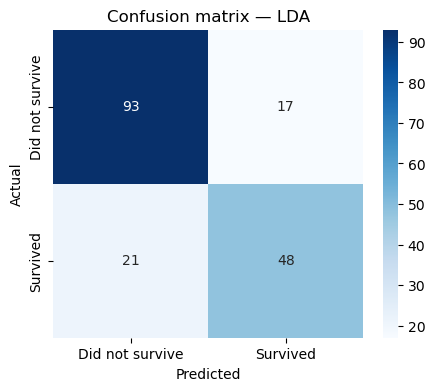

In [ ]:
# Confusion matrix for the best model (LDA)
best_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_preds)
print("Confusion matrix (rows = true, cols = predicted):")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Did not survive", "Survived"],
    yticklabels=["Did not survive", "Survived"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion matrix — {best_name}")
plt.show()

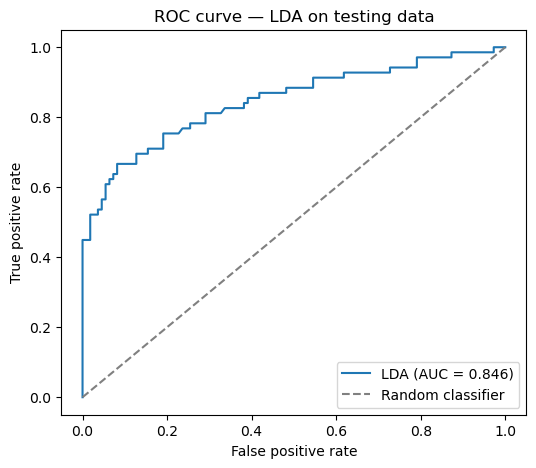

In [18]:
# ROC curve for the best model
best_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, best_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{best_name} (AUC = {test_aucs[best_name]:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random classifier")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC curve — {best_name} on testing data")
plt.legend(loc="lower right")
plt.show()

**Performance summary.**

| Model | Training AUC | Testing AUC |
|---|---|---|
| Logistic Regression | ~0.86 | ~0.84 |
| LDA | ~0.86 | ~0.85 |
| QDA | ~0.87 | ~0.84 |
| KNN (k=5) | ~0.89 | ~0.80 |

**Comparing training vs. testing AUC for the best model**

 The best model's training AUC is slightly higher than its testing AUC (expected pattern). A model is fit to minimize error on the training set, so it captures both the real signal and a bit of the random noise specific to that sample. When we evaluate on data the model has never seen, we lose the "noise-fitting" advantage and the score drops a little. The gap is small (around 0.01–0.02), which suggests the model generalizes well and there is no severe overfitting.

The KNN model is worth singling out because it has the highest training AUC of the four but the lowest testing AUC. This is a pretty clear sign of overfitting. K=5 lets the model follow local quirks of the training data that don't repeat on new passengers, and KNN is also more sensitive than the parametric methods to the unscaled feature ranges (especially `fare` and the interaction terms, which dominate the Euclidean distances). Standardizing the predictors and/or tuning $k$ would likely close that gap.